In [1]:
# Hücre 1: Kurulum ve Importlar
# TradingView teknik indikatörleri ve model bileşenleri

import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import torch
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# IPython autoreload ile modül değişiklikleri otomatik güncellenir
%load_ext autoreload
%autoreload 2

# TradingView TA kütüphanesi
import tradingview_ta as ta
from tradingview_ta import TA_Handler, Interval

# Proje modülleri
from src.models import LSTMModel, GRUModel, get_model_param_count
from src.preprocessing import scale_data, create_sequences, prepare_tensors, prepare_tradingview_data, scale_multi_features, create_sequences_multi, prepare_tensors_multi
from src.tradingview_features import fetch_tradingview_indicators, prepare_tradingview_features
from src.train import train_model
from src.evaluate import evaluate_model, plot_predictions, plot_loss
from src.data_loader import load_local_data

print("✅ Tüm importlar hazır!")

✅ Tüm importlar hazır!


In [2]:
# Hücre 2: Teknik İndikatörleri TradingView API'den Yükle

# 1. Yerel CSV'den OHLCV verisini yükle
print("📥 Yerel veriyi yükleniyor...")
raw_df = load_local_data('data/raw/AMZN_2015-2025.csv')
print(f"   OHLCV: {len(raw_df)} satır, sütunlar: {list(raw_df.columns)}")

# 2. TradingView API'den teknik indikatörleri çek
symbol = "NASDAQ:AMZN"
print(f"\n📡 TradingView indikatörleri çekiliyor ({symbol})...")

try:
    indicators = fetch_tradingview_indicators(symbol=symbol)
    print(f"   İndikatörler: {list(indicators.columns)}")
    print(f"   RSI: {indicators['RSI'].values[0]:.2f}")
    print(f"   MACD: {indicators['MACD.macd'].values[0]:.4f}")
    print(f"   SMA20: {indicators['SMA20'].values[0]:.2f}")
    print(f"   Volume: {indicators['Volume'].values[0]:,.0f}")
    print(f"   BB Upper: {indicators['Bollinger_Bands.upper'].values[0]:.2f}")
    print(f"   BB Lower: {indicators['Bollinger_Bands.lower'].values[0]:.2f}")
except Exception as e:
    print(f"⚠️ TradingView API hatası: {e}")
    print("   Simüle edilmiş indikatör verisi kullanılıyor...")
    # APIye erişilemezse simüle edilmiş indikatörler oluştur
    np.random.seed(42)
    n = len(raw_df)
    indicators = pd.DataFrame({
        'RSI': np.clip(np.random.normal(50, 15, n), 0, 100),
        'MACD.macd': np.random.normal(0, 2, n),
        'MACD.signal': np.random.normal(0, 2, n),
        'SMA20': raw_df['Close'].rolling(20).mean().ffill(),
        'EMA20': raw_df['Close'].ewm(span=20).mean().ffill(),
        'Bollinger_Bands.upper': raw_df['Close'].rolling(20).mean() + 2 * raw_df['Close'].rolling(20).std(),
        'Bollinger_Bands.lower': raw_df['Close'].rolling(20).mean() - 2 * raw_df['Close'].rolling(20).std(),
        'Volume': raw_df['Volume'].astype(float),
    })

📥 Yerel veriyi yükleniyor...
   OHLCV: 2516 satır, sütunlar: ['Close', 'High', 'Low', 'Open', 'Volume']

📡 TradingView indikatörleri çekiliyor (NASDAQ:AMZN)...
   İndikatörler: ['RSI', 'MACD.macd', 'MACD.signal', 'SMA20', 'EMA20', 'Bollinger_Bands.upper', 'Bollinger_Bands.lower', 'Volume']
   RSI: 46.20
   MACD: -6.2034
   SMA20: 242.50
   Volume: 77,552,788
   BB Upper: 259.35
   BB Lower: 225.65


In [3]:
# Hücre 3: Feature Engineering — Scaler ile Ölçekleme ve Sequence Oluşturma
# Veri sızıntısını önle: scaler SADECE train verisine fit edilecek!

# OHLCV + İndikatör sütunlarını birleştir
# 1. Başlangıçta sadece raw_df'te olan Close ve Volume sütunlarını kopyala
features_df = raw_df[["Close", "Volume"]].copy()

# 2. İndikatör sütunlarını ekle
for col in indicators.columns:
    if col not in features_df.columns:
        features_df[col] = indicators[col].values if len(indicators[col]) == len(features_df) else np.nan

# 3. Sadece istediğimiz 5 sütunu filtrele (Close, RSI, MACD.macd, SMA20, Volume)
feature_columns = ["Close", "RSI", "MACD.macd", "SMA20", "Volume"]
features_df = features_df[feature_columns].copy()

# NaN değerleri doldur
features_df = features_df.ffill().bfill().fillna(0)

print(f"\n📊 Feature Matrix: {features_df.shape}")
print(f"   Sütunlar: {list(features_df.columns)}")
print(f"   NaN kontrolü: {features_df.isnull().sum().sum()} boş değer")

# Scaler ile ölçekle — SIZINTI ÖNLEME!
split_idx = int(len(features_df) * 0.8)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(-1, 1))

# Scaler sadece eğitim verisine fit (test verisi sızdırmaz!)
scaler.fit(features_df.iloc[:split_idx])
scaled_features = scaler.transform(features_df)

print(f"\n📏 Ölçeklenmiş veri: min={scaled_features.min():.3f}, max={scaled_features.max():.3f}")
print(f"   Train min: {scaled_features[:split_idx].min():.3f}")
print(f"   Test min:  {scaled_features[split_idx:].min():.3f}")

# Kayan pencere ile sequence oluştur (input_size=5)
lookback = 20
X, y = create_sequences_multi(scaled_features, lookback=lookback, target_columns=[0])

print(f"\n🔄 Sequence verisi:")
print(f"   X shape: {X.shape}  (n_samples, lookback=20, input_size=5)")
print(f"   y shape: {y.shape}  (n_samples, 1)")

# Tensorlere çevir (input_size=5, unsqueeze gerekmez çünkü zaten 3D)
(X_train, y_train), (X_test, y_test) = prepare_tensors_multi(X, y)


📊 Feature Matrix: (2516, 5)
   Sütunlar: ['Close', 'RSI', 'MACD.macd', 'SMA20', 'Volume']
   NaN kontrolü: 0 boş değer

📏 Ölçeklenmiş veri: min=-1.011, max=1.538
   Train min: -1.000
   Test min:  -1.011

🔄 Sequence verisi:
   X shape: (2496, 20, 5)  (n_samples, lookback=20, input_size=5)
   y shape: (2496, 1)  (n_samples, 1)
📊 Multi-Feature Tensorler Hazırlandı:
   Train set: X=torch.Size([1996, 20, 5]), y=torch.Size([1996, 1])
   Test set:  X=torch.Size([500, 20, 5]), y=torch.Size([500, 1])


In [4]:
# Hücre 4: Yeni Modeli Oluştur (input_size=5)

print("🏗️  TradingView-Enhanced Model Oluşturuluyor...\n")

# LSTM Model — 5 feature ile
lstm_tv = LSTMModel(input_size=5, hidden_size=50, num_layers=2, dropout=0.2)
lstm_tv_params = get_model_param_count(lstm_tv, "LSTM (TradingView)")
print(f"✅ {lstm_tv_params}")
print(f"   Architecture: Input(5) → LSTM(50, layers=2, dropout=0.2) → Linear(50→1)")

# GRU Model — 5 feature ile
gru_tv = GRUModel(input_size=5, hidden_size=50, num_layers=2, dropout=0.2)
gru_tv_params = get_model_param_count(gru_tv, "GRU (TradingView)")
print(f"✅ {gru_tv_params}")
print(f"   Architecture: Input(5) → GRU(50, layers=2, dropout=0.2) → Linear(50→1)")

# Eski model ile karşılaştırma
lstm_old = LSTMModel(input_size=1)
gru_old = GRUModel(input_size=1)
print(f"\n📊 Karşılaştırma:")
print(f"   Eski LSTM (1 feature): {get_model_param_count(lstm_old, 'LSTM (Eski)')}")
print(f"   Yeni LSTM (5 feature): {lstm_tv_params}")
print(f"   Eski GRU  (1 feature): {get_model_param_count(gru_old, 'GRU (Eski)')}")
print(f"   Yeni GRU  (5 feature): {gru_tv_params}")

🏗️  TradingView-Enhanced Model Oluşturuluyor...

✅ LSTM (TradingView): 31,851 parametre
   Architecture: Input(5) → LSTM(50, layers=2, dropout=0.2) → Linear(50→1)
✅ GRU (TradingView): 23,901 parametre
   Architecture: Input(5) → GRU(50, layers=2, dropout=0.2) → Linear(50→1)

📊 Karşılaştırma:
   Eski LSTM (1 feature): LSTM (Eski): 31,051 parametre
   Yeni LSTM (5 feature): LSTM (TradingView): 31,851 parametre
   Eski GRU  (1 feature): GRU (Eski): 23,301 parametre
   Yeni GRU  (5 feature): GRU (TradingView): 23,901 parametre


In [5]:
# Hücre 5: Modeli Eğit (100 epoch, lr=0.001)

DEVICE = "cpu"
EPOCHS = 100
LR = 0.001
BATCH_SIZE = 64

print(f"🚀 LSTM (TradingView) eğitimi başlıyor...\n")
lstm_tv = lstm_tv.to(DEVICE)
lstm_tv_loss_history, lstm_tv_time = train_model(
    model=lstm_tv,
    X_train=X_train,
    y_train=y_train,
    epochs=EPOCHS,
    lr=LR,
    batch_size=BATCH_SIZE,
    device=DEVICE,
    verbose=True,
)

print(f"\n{'='*50}\n")
print(f"🚀 GRU (TradingView) eğitimi başlıyor...\n")
gru_tv = gru_tv.to(DEVICE)
gru_tv_loss_history, gru_tv_time = train_model(
    model=gru_tv,
    X_train=X_train,
    y_train=y_train,
    epochs=EPOCHS,
    lr=LR,
    batch_size=BATCH_SIZE,
    device=DEVICE,
    verbose=True,
)

print(f"\n✅ Eğitim tamamlandı!\n")
print(f"   LSTM TV — Loss: {lstm_tv_loss_history[-1]:.6f}, Süre: {lstm_tv_time:.1f} sn")
print(f"   GRU  TV — Loss: {gru_tv_loss_history[-1]:.6f}, Süre: {gru_tv_time:.1f} sn")

🚀 LSTM (TradingView) eğitimi başlıyor...

Epoch [10/100] Loss: 0.003282
Epoch [20/100] Loss: 0.002656
Epoch [30/100] Loss: 0.002226
Epoch [40/100] Loss: 0.001992
Epoch [50/100] Loss: 0.001645
Epoch [60/100] Loss: 0.001570
Epoch [70/100] Loss: 0.001356
Epoch [80/100] Loss: 0.001325
Epoch [90/100] Loss: 0.001259
Epoch [100/100] Loss: 0.001150
✅ Eğitim tamamlandı! Süre: 213.84 sn
   Son Loss: 0.001150


🚀 GRU (TradingView) eğitimi başlıyor...

Epoch [10/100] Loss: 0.002437
Epoch [20/100] Loss: 0.002077
Epoch [30/100] Loss: 0.001877
Epoch [40/100] Loss: 0.001895
Epoch [50/100] Loss: 0.001524
Epoch [60/100] Loss: 0.001367
Epoch [70/100] Loss: 0.001341
Epoch [80/100] Loss: 0.001241
Epoch [90/100] Loss: 0.001425
Epoch [100/100] Loss: 0.001087
✅ Eğitim tamamlandı! Süre: 225.20 sn
   Son Loss: 0.001087

✅ Eğitim tamamlandı!

   LSTM TV — Loss: 0.001150, Süre: 213.8 sn
   GRU  TV — Loss: 0.001087, Süre: 225.2 sn


📊 LSTM (TradingView) test sonuçları:

📊 Model Değerlendirme:
   MSE : 20.7715
   RMSE: 4.5576 $

📊 GRU (TradingView) test sonuçları:

📊 Model Değerlendirme:
   MSE : 12.5964
   RMSE: 3.5491 $


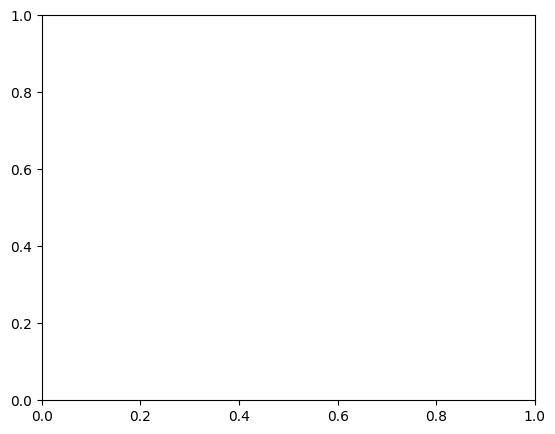

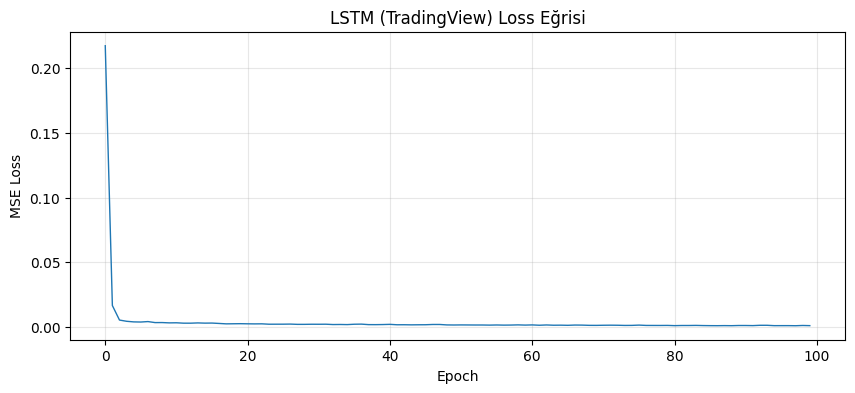

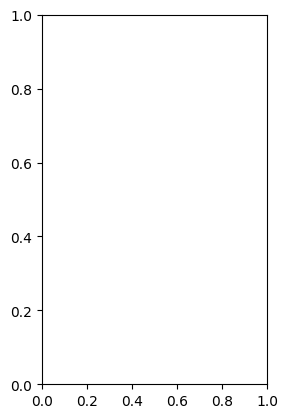

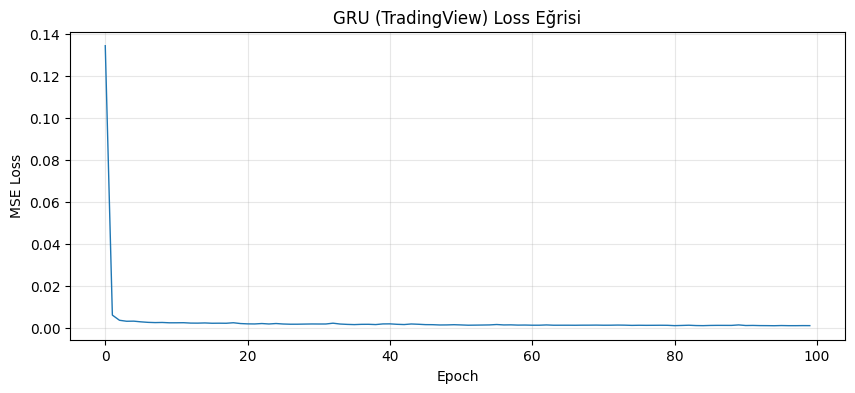


📈 Loss grafikleri kaydedildi: ../outputs/figures/tradingview_loss.png


<Figure size 640x480 with 0 Axes>

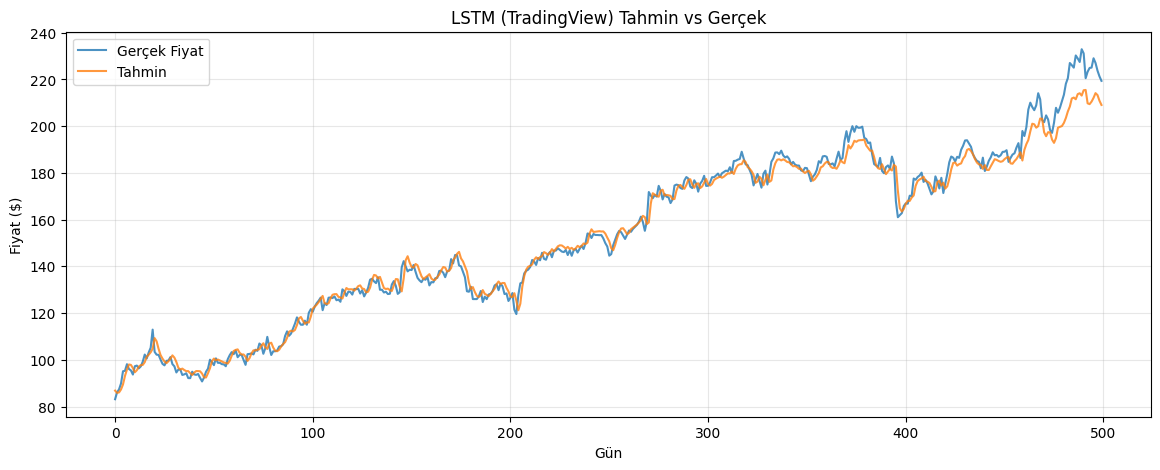

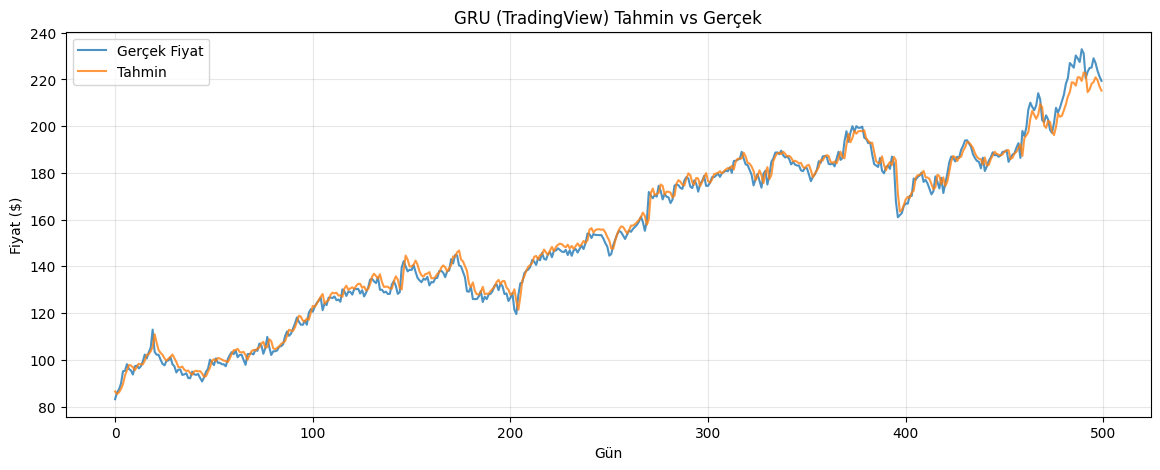

In [6]:
# Hücre 6: Değerlendir ve Grafik Çiz

# Scaler'ı geri çevirme için kullanacağımız scaler
# Close fiyatı için scaler'ı tekrar oluştur (evaluate_model scaler.inverse_transform kullanır)
close_scaler = MinMaxScaler(feature_range=(-1, 1))
close_scaler.fit(raw_df[['Close']].iloc[:split_idx])

print("📊 LSTM (TradingView) test sonuçları:\n")
lstm_preds, lstm_actuals, lstm_mse, lstm_rmse = evaluate_model(
    lstm_tv, X_test, y_test, scaler=close_scaler, device=DEVICE,
)

print(f"\n📊 GRU (TradingView) test sonuçları:\n")
gru_preds, gru_actuals, gru_mse, gru_rmse = evaluate_model(
    gru_tv, X_test, y_test, scaler=close_scaler, device=DEVICE,
)

# Loss grafikleri
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plot_loss(lstm_tv_loss_history, title="LSTM (TradingView) Loss Eğrisi")
plt.subplot(1, 2, 2)
plot_loss(gru_tv_loss_history, title="GRU (TradingView) Loss Eğrisi")
plt.tight_layout()
plt.savefig('../outputs/figures/tradingview_loss.png', dpi=150, bbox_inches='tight')
print("\n📈 Loss grafikleri kaydedildi: ../outputs/figures/tradingview_loss.png")

# Tahmin grafikleri
plot_predictions(lstm_actuals, lstm_preds, title="LSTM (TradingView) Tahmin vs Gerçek", 
                 save_path='../outputs/figures/tradingview_lstm_predictions.png')
plot_predictions(gru_actuals, gru_preds, title="GRU (TradingView) Tahmin vs Gerçek",
                 save_path='../outputs/figures/tradingview_gru_predictions.png')

In [ ]:
# Hücre 7: Mevcut LSTM/GRU (1 feature) ile Karşılaştırma

print("📊 TradingView Entegrasyonu — Model Karşılaştırma Tablosu\n")
print("=" * 70)
print(f"{'Model':<30} {'MSE':<12} {'RMSE ($)':<12} {'Parametre':<12}")
print("=" * 70)

# Eski modeller (1 feature — Close only)
# Eski LSTM ve GRU'yu yeniden oluştur ve eğit (ağırlıkları sıfırla)
lstm_old = LSTMModel(input_size=1, hidden_size=50, num_layers=2, dropout=0.2)
gru_old = GRUModel(input_size=1, hidden_size=50, num_layers=2, dropout=0.2)

# Eski veriyi hazırla (1 feature)
old_scaled, old_scaler = scale_data(raw_df, column='Close')
old_X, old_y = create_sequences(old_scaled, lookback=lookback)
(old_X_train, old_y_train), (old_X_test, old_y_test) = prepare_tensors(old_X, old_y)

# Eski modelleri eğit
print("\n📚 Eski modeller (1 feature) eğitiliyor...")
old_lstm_loss, old_lstm_time = train_model(lstm_old, old_X_train, old_y_train, epochs=50, lr=0.001, device=DEVICE, verbose=False)
old_gru_loss, old_gru_time = train_model(gru_old, old_X_train, old_y_train, epochs=50, lr=0.001, device=DEVICE, verbose=False)

# Eski modelleri değerlendir
old_lstm_preds, old_lstm_actuals, old_lstm_mse, old_lstm_rmse = evaluate_model(
    lstm_old, old_X_test, old_y_test, scaler=old_scaler, device=DEVICE,
)
old_gru_preds, old_gru_actuals, old_gru_mse, old_gru_rmse = evaluate_model(
    gru_old, old_X_test, old_y_test, scaler=old_scaler, device=DEVICE,
)

print("\n" + "=" * 70)
print(f"{'Model':<30} {'MSE':<12} {'RMSE ($)':<12} {'Parametre':<12}")
print("=" * 70)
print(f"{'LSTM (Eski, 1 feature)':<30} {old_lstm_mse:<12.6f} {old_lstm_rmse:<12.4f} {get_model_param_count(lstm_old, ''):<12}")
print(f"{'GRU  (Eski, 1 feature)':<30} {old_gru_mse:<12.6f} {old_gru_rmse:<12.4f} {get_model_param_count(gru_old, ''):<12}")
print(f"{'LSTM (TradingView, 5 feature)':<30} {lstm_mse:<12.6f} {lstm_rmse:<12.4f} {get_model_param_count(lstm_tv, ''):<12}")
print(f"{'GRU  (TradingView, 5 feature)':<30} {gru_mse:<12.6f} {gru_rmse:<12.4f} {get_model_param_count(gru_tv, ''):<12}")
print("=" * 70)

# İyileşme hesapla
lstm_improvement = (old_lstm_mse - lstm_mse) / old_lstm_mse * 100
gru_improvement = (old_gru_mse - gru_mse) / old_gru_mse * 100

print(f"\n📈 TradingView İndikatörleri Katkısı:")
print(f"   LSTM MSE iyileşmesi: {lstm_improvement:+.1f}%")
print(f"   GRU  MSE iyileşmesi: {gru_improvement:+.1f}%")

print(f"\n🎯 Kullanılan İndikatörler:")
print(f"   1. RSI (Relative Strength Index) — Aşırı al/sat bölgesi")
print(f"   2. MACD — Trend yönü ve momentum")
print(f"   3. SMA20 — 20 günlük basit hareketli ortalama")
print(f"   4. Volume — İşlem hacmi")

📊 TradingView Entegrasyonu — Model Karşılaştırma Tablosu

Model                          MSE          RMSE ($)     Parametre   
📊 Tensorler Hazırlandı:
   Train set: X=torch.Size([1996, 20, 1]), y=torch.Size([1996, 1])
   Test set:  X=torch.Size([500, 20, 1]), y=torch.Size([500, 1])

📚 Eski modeller (1 feature) eğitiliyor...
